In [234]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold, RandomizedSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, auc, roc_curve, mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

In [226]:
# Load the dataset
df = pd.read_csv('../data/engineered/dataset_mood_smartphone_non_ts_7_day_rolling_window.csv')
print(df.shape)
df.head()

(1418, 15)


,id,last_date,avg_last_day_mood,activity,mood,screen,emotion,count_call_and_sms,total_app_use,social_ratio,productive_ratio,passive_entertainment_ratio,adventure_ratio,miscellaneous_ratio,is_last_day
0,AS14.01,2014-03-16,7.075177,0.080856,7.075177,0.0,-0.185139,3.467093,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AS14.01,2014-03-17,7.075177,0.080856,7.075177,0.0,-0.185139,3.654149,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AS14.01,2014-03-18,7.075177,0.080856,7.075177,0.0,-0.185139,3.170067,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AS14.01,2014-03-19,7.075177,0.080856,7.075177,0.0,-0.185139,2.575119,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AS14.01,2014-03-20,7.075177,0.080856,7.075177,0.0,-0.185139,2.077968,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Classification

Rather than utilizing a single threshold for binary classification, we framed the task as a multiclass classification problem to capture a more refined understanding of the user's mood. The target variable was discretized into three distinct categories: low (score ≤ 6.5), average (6.5 < score ≤ 7.2), and high (score > 7.2). These specific thresholds were selected to ensure a relatively balanced class distribution across the dataset.

In [217]:
# define the threshold for the target variable
def define_mood_label(mood_score):
    if mood_score <= 7:
        return 'Low'
    else:
        return 'High'

In [218]:
# apply the function to create the 'mood' column
df['mood_class'] = df['avg_last_day_mood'].apply(define_mood_label)   
print(df['mood_class'].value_counts())

mood_class
Low     794
High    624
Name: count, dtype: int64


To mitigate the risk of data leakage, the dataset was partitioned into training and testing subsets utilizing a GroupShuffleSplit approach. This keeps each person's entire timeline together in either the training or testing set.

In [196]:
X, y = df.drop(columns=['avg_last_day_mood', 'mood_class', 'id', 'last_date', 'is_last_day']), df['mood_class']
# define the groups based on the 'id' column
groups = df['id']
# split the data using GroupShuffleSplit to ensure that all samples from the same group are in the same split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print(y_test.value_counts())

Training set shape: (1121, 11)
Test set shape: (297, 11)
mood_class
Low     157
High    140
Name: count, dtype: int64


## Random Forest

To optimize the hyperparameters, we performed a grid search combined with a $k$-fold cross-validation approach. Specifically, we utilized GroupKFold to strictly isolate individual users across folds, thereby mitigating the risk of data leakage between the training and validation sets. The hyperparameter search space evaluated the number of trees in the forest, maximum tree depth, class weight adjustments for data imbalance, minimum sample thresholds for splits and leaves, and the maximum number of features considered per split.

In [197]:
clf = RandomForestClassifier(random_state=42)
gkf = GroupKFold(n_splits=5)

# set up RFECV
selector = RFECV(estimator=clf, step=1, cv=gkf, scoring='f1_macro', n_jobs=-1)
selector.fit(X_train, y_train, groups=groups.iloc[train_idx])
print("Optimal number of features: %d" % selector.n_features_)
print("Selected features: %s" % list(X_train.columns[selector.support_]))

Optimal number of features: 7
Selected features: ['activity', 'mood', 'screen', 'emotion', 'count_call_and_sms', 'total_app_use', 'social_ratio']


In [198]:
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

In [ ]:
# find the best hyperparameters for the Random Forest Classifier using GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],                        # number of trees in the forest
    'max_depth': [3, 5],                                    # maximum depth of the tree
    'criterion': ['gini', 'entropy'],                       # function to measure the quality of a split                    
    'class_weight': ['balanced', 'balanced_subsample'],     # weights associated with classes
    'min_samples_split': [2, 5],                            # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2],                             # minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'],                       # number of features to consider when looking for the best split
}
# use GroupKFold for cross-validation to ensure that samples from the same group are not split between training and validation sets
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=gkf, scoring='f1_macro')
grid_search.fit(X_train_selected, y_train, groups=groups.iloc[train_idx])
print("Best hyperparameters:", grid_search.best_params_)

Best hyperparameters: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [220]:
# train the Random Forest Classifier with the best hyperparameters
best_clf = grid_search.best_estimator_
# make predictions on the test set
y_pred = best_clf.predict(X_test_selected)

In [221]:
# evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score'])
print("Precision:", classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision'])
print("Recall:", classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall'])

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.59      0.63       140
         Low       0.67      0.74      0.70       157

    accuracy                           0.67       297
   macro avg       0.67      0.67      0.67       297
weighted avg       0.67      0.67      0.67       297

Accuracy: 0.67003367003367
F1 Score: 0.6680338740944801
Precision: 0.669970887945902
Recall: 0.67003367003367


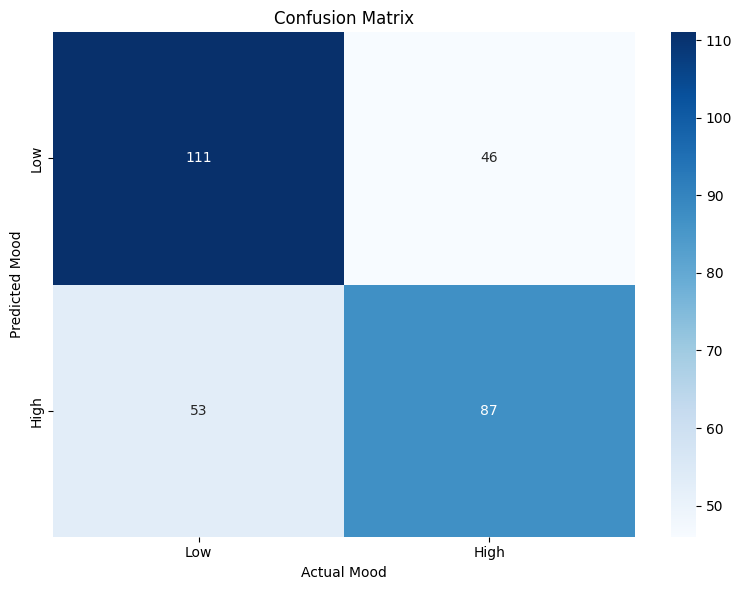

In [209]:
# plot the confusion matrix
class_labels = ['Low', 'High']
cm = confusion_matrix(y_test, y_pred, labels=class_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)  

plt.title('Confusion Matrix')
plt.xlabel('Actual Mood')
plt.ylabel('Predicted Mood')
plt.tight_layout()
plt.savefig('conf_matrix.pdf', format='pdf', bbox_inches='tight')
plt.show()

<Figure size 1000x800 with 0 Axes>

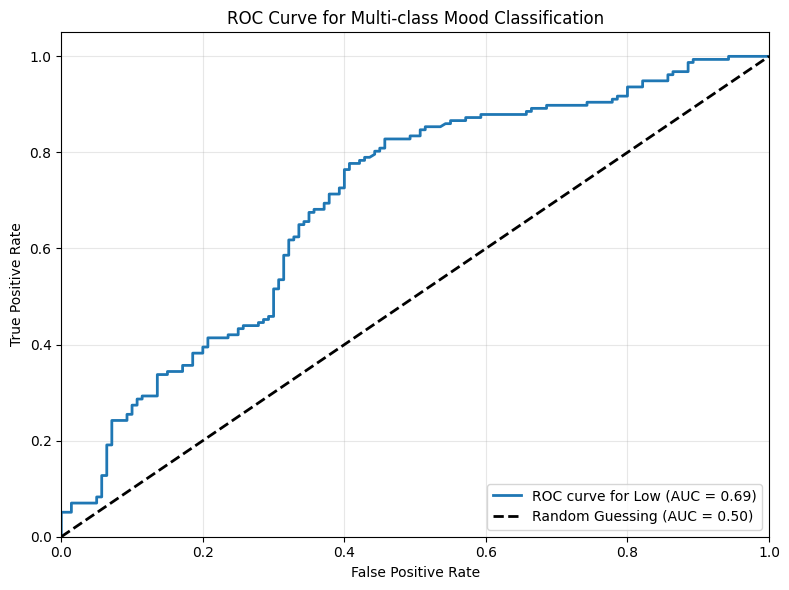

In [213]:
# ROC curve and AUC

pos_class = best_clf.classes_[1] 
y_score = best_clf.predict_proba(X_test_selected)[:, 1]

plt.figure(figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=pos_class)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2,
         label=f'ROC curve for {pos_class} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class Mood Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Regression

In [227]:
X_r, y_r = df.drop(columns=['avg_last_day_mood', 'id', 'last_date', 'is_last_day']), df['avg_last_day_mood']
# define the groups based on the 'id' column
groups_r = df['id']
# split the data using GroupShuffleSplit to ensure that all samples from the same group are in the same split
gss_r = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X_r, y_r, groups_r):
    X_train_r, X_test_r = X_r.iloc[train_idx], X_r.iloc[test_idx]
    y_train_r, y_test_r = y_r.iloc[train_idx], y_r.iloc[test_idx]

print("Training set shape:", X_train_r.shape)
print("Test set shape:", X_test_r.shape)

Training set shape: (1121, 11)
Test set shape: (297, 11)


In [231]:
reg = RandomForestRegressor(random_state=42)
gkf = GroupKFold(n_splits=5)

# set up RFECV
selector = RFECV(estimator=reg, step=1, cv=gkf, scoring='neg_mean_absolute_error', n_jobs=-1)
selector.fit(X_train_r, y_train_r, groups=groups.iloc[train_idx])
print("Optimal number of features: %d" % selector.n_features_)
print("Selected features: %s" % list(X_train_r.columns[selector.support_]))

Optimal number of features: 11
Selected features: ['activity', 'mood', 'screen', 'emotion', 'count_call_and_sms', 'total_app_use', 'social_ratio', 'productive_ratio', 'passive_entertainment_ratio', 'adventure_ratio', 'miscellaneous_ratio']


In [235]:
X_train_selected_r = selector.transform(X_train_r)
X_test_selected_r = selector.transform(X_test_r)

In [245]:
# find the best hyperparameters for the Random Forest Classifier 
param_grid = {
    'n_estimators': [100, 200, 300],                        # number of trees in the forest
    'max_depth': [3, 5, None],                              # maximum depth of the tree                  
    'min_samples_split': [2, 5, 10],                        # minimum number of samples required to split an internal node
    'criterion': ['squared_error', 'absolute_error'],       # function to measure the quality of a split
    'min_samples_leaf': [1, 2, 4],                          # minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 1.0],                  # number of features to consider when looking for the best split
}
# use GroupKFold for cross-validation to ensure that samples from the same group are not split between training and validation sets
grid_search = GridSearchCV(estimator=reg, param_grid=param_grid, cv=gkf, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train_selected_r, y_train_r, groups=groups.iloc[train_idx])
print("Best hyperparameters:", grid_search.best_params_)

Best hyperparameters: {'criterion': 'absolute_error', 'max_depth': 5, 'max_features': 1.0, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [240]:
# train the Random Forest Classifier with the best hyperparameters
best_reg = grid_search.best_estimator_
# make predictions on the test set
y_pred_r = best_reg.predict(X_test_selected_r)

In [241]:
# evaluate the model
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Absolute Error: 0.37658904833519224
Mean Squared Error: 0.2713542826710979
R^2 Score: 0.28104175076718374


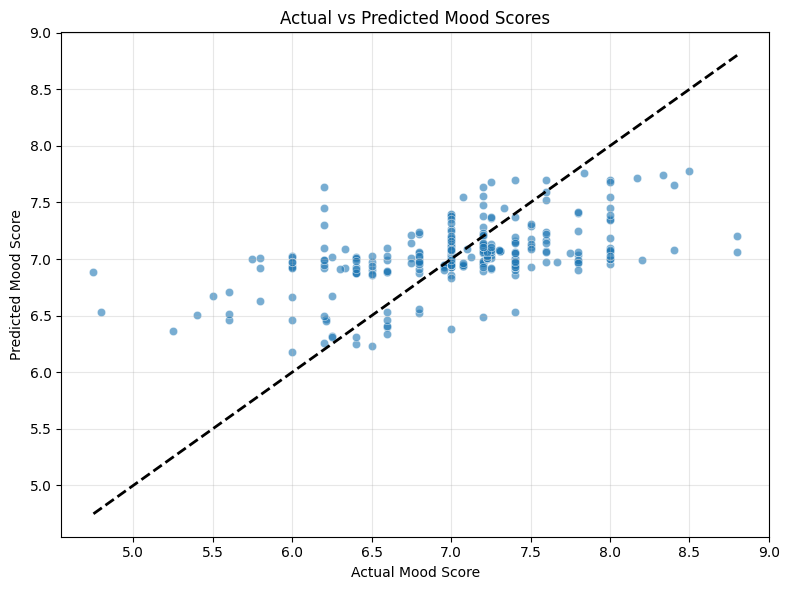

In [242]:
# scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'k--', lw=2)
plt.xlabel('Actual Mood Score')
plt.ylabel('Predicted Mood Score')
plt.title('Actual vs Predicted Mood Scores')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.pdf', format='pdf', bbox_inches='tight')
plt.show()